1. OR 게이트 학습 및 시각화 (ANN)

In [1]:
# 라이브러리 import
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

# x1, x2 좌표
input = pd.DataFrame([(0, 0), (0, 1), (1, 0), (1, 1)], columns=['x1', 'x2'])
input

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [2]:
# 규칙에 따라 y 값 계산
or_gate_y = []
for i in range(len(input)):
  if input.loc[i, 'x1'] + input.loc[i, 'x2'] >= 1:
    or_gate_y.append(1)
  else:
    or_gate_y.append(0)

or_gate_y

[0, 1, 1, 1]

In [3]:
#or_gate 완성
or_gate = input.assign(y=or_gate_y)
or_gate

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [4]:
# x1+x2=0.5 직선을 기준으로 분류
def seperate(x1, x2):
  if x1 + x2 > 0.5:
    return 1
  else:
    return 0

for i in range(len(input)):
  print(seperate(input.loc[i, 'x1'], input.loc[i, 'x2']))

0
1
1
1


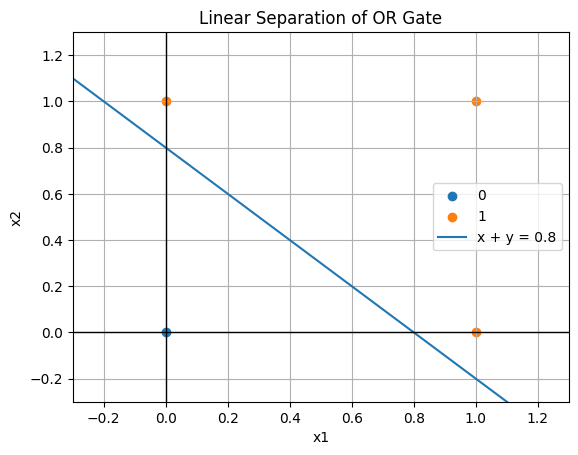

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.scatter(or_gate[or_gate['y']==0]['x1'], or_gate[or_gate['y']==0]['x2'], label='0')
ax.scatter(or_gate[or_gate['y']==1]['x1'], or_gate[or_gate['y']==1]['x2'], label='1')

xs = [-2, 2]
ys = [0.8 - xs[0], 0.8 - xs[1]]
ax.plot(xs, ys, label='x + y = 0.8')

#좌표 평면 그리기
ax.grid(True)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# 배경 좌표
ax.set_xlabel('x1')
ax.set_ylabel('x2')

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)

ax.set_title('Linear Separation of OR Gate')
ax.legend()
plt.show()

2. XOR 게이트 학습 시도 및 한계 시각화 (ANN)

In [6]:
xor_gate_y = []
for i in range(len(input)):
  if input.loc[i, 'x1'] - input.loc[i, 'x2'] != 0:
    xor_gate_y.append(1)
  else:
    xor_gate_y.append(0)

xor_gate_y

[0, 1, 1, 0]

In [7]:
xor_gate = input.assign(y=xor_gate_y)
xor_gate

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [8]:
X = torch.tensor(xor_gate[['x1', 'x2']].values, dtype=torch.float32)
y = torch.tensor(xor_gate['y'].values, dtype=torch.float32).view(-1, 1)

#모델 구성(파이토치)
model_sl = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model_sl.parameters(), lr=0.01)

In [9]:
#모델 학습
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model_sl(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()

#예측값
with torch.no_grad():
    output = model_sl(X)
    print("Predictions:", (output.numpy() > 0.5).astype(int).flatten())

Predictions: [1 1 0 0]


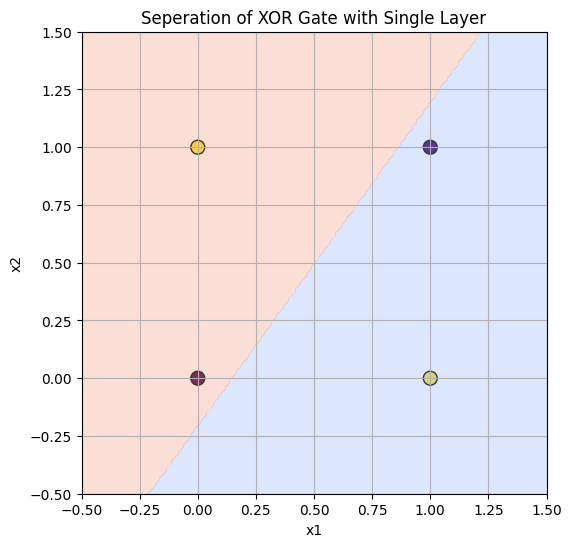

In [10]:
grid_x = np.linspace(-0.5, 1.5, 200)
grid_y = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(grid_x, grid_y)

grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    grid_pred = model_sl(grid_tensor).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.title('Seperation of XOR Gate with Single Layer')
plt.scatter(xor_gate['x1'], xor_gate['x2'], c=xor_gate['y'], s=100, edgecolors="k")
plt.contourf(xx, yy, grid_pred.numpy() > 0.5, alpha=0.3, cmap='coolwarm')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

3. XOR 게이트 학습 및 시각화 (DNN)

In [11]:
#모델
model_dl = nn.Sequential(
    nn.Linear(2, 4),
    nn.Tanh(),
    nn.Linear(4, 2),
    nn.Tanh(),
    nn.Linear(2, 1),
    nn.Sigmoid()

)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model_dl.parameters(), lr=0.01)

In [12]:
#학습
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model_dl(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()

#예측값
with torch.no_grad():
    output = model_dl(X)
    print("Predictions:", (output.numpy() > 0.5).astype(int).flatten())

Predictions: [0 1 1 1]


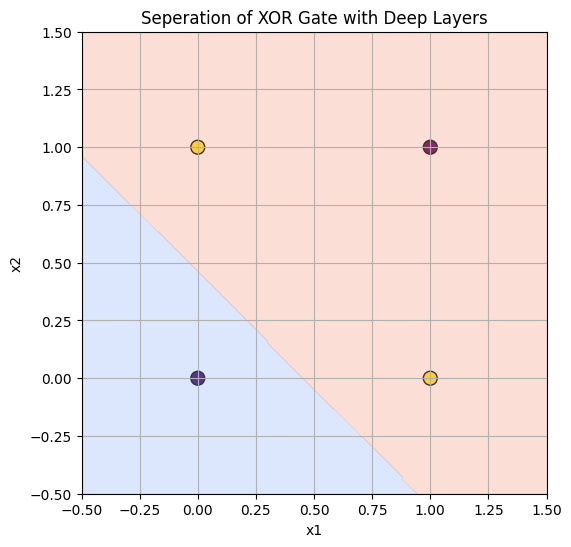

In [13]:
grid_x = np.linspace(-0.5, 1.5, 200)
grid_y = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    grid_pred = model_dl(grid_tensor).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.title('Seperation of XOR Gate with Deep Layers')
plt.scatter(xor_gate['x1'], xor_gate['x2'], c=xor_gate['y'], s=100, edgecolors="k")
plt.contourf(xx, yy, grid_pred.numpy() > 0.5, alpha=0.3, cmap='coolwarm')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

## 1. OR 게이트 분류 (ANN, 은닉층 1개)

* **선형 분리 가능**  
  - OR 데이터는 입력 공간에서 `x₁ + x₂ = 0.5` 같은 **하나의 직선(하이퍼플레인)** 으로 두 클래스를 나눌 수 있음.  

* **은닉층 1개라도 변화 없음**  
  - 은닉 노드가 한 개뿐이면 최종적으로는 위와 동일한 단일 결정경계로 수렴.  
* **시각화 요약**  
  - 직선 하나가 입력 평면을 두 반평면으로 분할, (0,0)만 클래스 0, 나머지는 클래스 1.

---

## 2. XOR 게이트 실패 원인 (ANN, 은닉층 노드 1개)

* **비선형(체커보드) 분포**  
  - 네 개 점이 대각선으로 교차 → **단일 직선으로는 분리 불가능**.  
* **은닉 노드 1개 한계**  
  - 구조: 입력 → 단조 활성(sigmoid/ReLU) → 선형 출력  
  - 활성 함수를 한 번 거친 뒤 다시 선형 결합하더라도 최종 결정경계는 여전히 **하나의 하이퍼플레인**.  
* **학습 결과**  
  - 손실이 0에 수렴하지 못하고 정확도 최대 50 % 부근에서 멈춤(두 점만 맞춤).  

---

## 3. XOR 게이트 분류 (DNN, 은닉 노드 ≥ 2)

* **다중 선형 경계 조합**  
  - 은닉 노드가 2개 이상이면 **서로 다른 방향**의 직선을 두 개 이상 학습 가능.  
  - 예시:  
    * 노드 1 → `x₁ > 0.5` 감지  
    * 노드 2 → `x₂ > 0.5` 감지  
* **결정 영역**  
  - 두 직선이 입력 평면을 네 구역으로 나눔 → 대각선 위치 두 칸만 클래스 1로 채색 → **완벽 분류**.  
* **왜 가능한가?**  
  - 깊거나 폭이 넓은 네트워크는 여러 하이퍼플레인을 **piece‑wise** 로 이어 붙여 복잡한 비선형 경계를 구현
* **시각화 요약**  
  - 입력 평면에 두 개의 직선(또는 ReLU 경사) → 네 사분면 중 두 곳이 클래스 1, 나머지 두 곳 클래스 0.

